# Langkah 1: Siapkan Dataset Mentah


In [1]:
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
elif not (project_root / "data" / "raw").exists():
    project_root = project_root.parent

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from preprocessing import (
    build_preprocessor,
    clean_cab_rides,
    create_time_features,
    get_feature_target,
    load_raw_data,
)
from train_model import (
    evaluate_model,
    save_model,
    train_baseline_models,
    train_test_split_data,
)

raw_path = project_root / "data" / "raw" / "cab_rides.csv"
processed_dir = project_root / "data" / "processed"
models_dir = project_root / "models"
reports_dir = project_root / "reports"

processed_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

cleaned_path = processed_dir / "cleaned_cab_rides.csv"
model_path = models_dir / "baseline_price_model.joblib"
report_path = reports_dir / "baseline_model_report.md"

print("Project root:", project_root)
print("Raw data path:", raw_path)






Project root: D:\SEMESTER 6\DATA MINING\MLOps-Tarif-Transportasi-Online
Raw data path: D:\SEMESTER 6\DATA MINING\MLOps-Tarif-Transportasi-Online\data\raw\cab_rides.csv


In [2]:
cab_rides = load_raw_data(raw_path)
rows_before_cleaning = len(cab_rides)

print("Shape sebelum cleaning:", cab_rides.shape)
display(cab_rides.head())






Shape sebelum cleaning: (693071, 10)


,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [3]:
cleaned_cab_rides = clean_cab_rides(cab_rides)
cleaned_cab_rides.to_csv(cleaned_path, index=False)
rows_after_cleaning = len(cleaned_cab_rides)

print("Shape setelah cleaning:", cleaned_cab_rides.shape)
display(cleaned_cab_rides.head())

Shape setelah cleaning: (637976, 10)


,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


# Langkah 2: Pembersihan Data


# Langkah 2b: Pemilihan Fitur

Model memprediksi `price` sebagai nilai tarif numerik. Kolom yang tidak relevan (id, product_id) akan dibuang.


In [4]:
model_data = create_time_features(cleaned_cab_rides)

time_preview_columns = ["time_stamp", "datetime", "hour", "day", "month", "day_of_week"]
display(model_data[time_preview_columns].head())






,time_stamp,datetime,hour,day,month,day_of_week
0,1544952607890,2018-12-16 09:30:07.890,9,16,12,6
1,1543284023677,2018-11-27 02:00:23.677,2,27,11,1
2,1543366822198,2018-11-28 01:00:22.198,1,28,11,2
3,1543553582749,2018-11-30 04:53:02.749,4,30,11,4
4,1543463360223,2018-11-29 03:49:20.223,3,29,11,3


In [5]:
X, y, feature_columns, numeric_features, categorical_features = get_feature_target(
    model_data,
    include_surge=False,
)
target_column = "price"

# Langkah 3: Feature Engineering


In [6]:
feature_group_summary = pd.DataFrame({
    "Grup Fitur": ["Numerical", "Categorical"],
    "Kolom": [", ".join(numeric_features), ", ".join(categorical_features)],
})

display(feature_group_summary)
display(X.head())






,Grup Fitur,Kolom
0,Numerical,"distance, hour, day, month, day_of_week"
1,Categorical,"cab_type, source, destination, name"


,distance,cab_type,source,destination,name,hour,day,month,day_of_week
0,0.44,Lyft,Haymarket Square,North Station,Shared,9,16,12,6
1,0.44,Lyft,Haymarket Square,North Station,Lux,2,27,11,1
2,0.44,Lyft,Haymarket Square,North Station,Lyft,1,28,11,2
3,0.44,Lyft,Haymarket Square,North Station,Lux Black XL,4,30,11,4
4,0.44,Lyft,Haymarket Square,North Station,Lyft XL,3,29,11,3


# Langkah 3b: Preprocessing Pipeline

Preprocessing dibutuhkan karena model ML tidak bisa langsung membaca data kategorikal mentah. Kita pakai OneHotEncoder dan StandardScaler.


In [7]:
preprocessor = build_preprocessor(numeric_features, categorical_features, scale_numeric=True)

preprocessing_summary = pd.DataFrame({
    "Tipe Kolom": ["Numerical", "Categorical"],
    "Kolom": [", ".join(numeric_features), ", ".join(categorical_features)],
    "Transformasi": ["StandardScaler", "OneHotEncoder(handle_unknown='ignore')"],
})

display(preprocessing_summary)
print("Logika preprocessing disimpan di:", project_root / "src" / "preprocessing.py")
preprocessor






,Tipe Kolom,Kolom,Transformasi
0,Numerical,"distance, hour, day, month, day_of_week",StandardScaler
1,Categorical,"cab_type, source, destination, name",OneHotEncoder(handle_unknown='ignore')


Logika preprocessing disimpan di: D:\SEMESTER 6\DATA MINING\MLOps-Tarif-Transportasi-Online\src\preprocessing.py


,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


# Langkah 4: Training Model Baseline


In [8]:
X_train, X_test, y_train, y_test = train_test_split_data(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Shape fitur training:", X_train.shape)
print("Shape fitur testing:", X_test.shape)
print("Shape target training:", y_train.shape)
print("Shape target testing:", y_test.shape)






Shape fitur training: (510380, 9)
Shape fitur testing: (127596, 9)
Shape target training: (510380,)
Shape target testing: (127596,)


In [9]:
trained_models = train_baseline_models(
    preprocessor,
    X_train,
    y_train,
    random_state=42,
    rf_sample_size=100_000,
)

models_trained = list(trained_models.keys())

print("Model yang dilatih:")
for model_name in models_trained:
    print("-", model_name)

print("\nLogika training disimpan di:", project_root / "src" / "train_model.py")






Model yang dilatih:
- Dummy Regressor
- Ridge Regression
- Random Forest Regressor

Logika training disimpan di: D:\SEMESTER 6\DATA MINING\MLOps-Tarif-Transportasi-Online\src\train_model.py


# Langkah 5: Evaluasi Hasil


In [10]:
evaluation_results = []

for model_name, model in trained_models.items():
    metrics = evaluate_model(model, X_test, y_test)
    evaluation_results.append({
        "Model": model_name,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2 Score": metrics["R2 Score"],
    })

results_df = pd.DataFrame(evaluation_results).sort_values("MAE").reset_index(drop=True)
display(results_df)






,Model,MAE,RMSE,R2 Score
0,Random Forest Regressor,1.425413,2.618088,9.213770e-01
1,Ridge Regression,1.928243,3.037824,8.941462e-01
2,Dummy Regressor,7.559787,9.337046,-1.455636e-07


In [11]:
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_metrics = results_df.loc[0].to_dict()

save_model(best_model, model_path)

print("Model terbaik berdasar MAE:", best_model_name)
print(f"MAE: {best_metrics['MAE']:.4f}")
print(f"RMSE: {best_metrics['RMSE']:.4f}")
print(f"R2 Score: {best_metrics['R2 Score']:.4f}")
print("Lokasi model:", model_path)






Model terbaik berdasar MAE: Random Forest Regressor
MAE: 1.4254
RMSE: 2.6181
R2 Score: 0.9214
Lokasi model: D:\SEMESTER 6\DATA MINING\MLOps-Tarif-Transportasi-Online\models\baseline_price_model.joblib


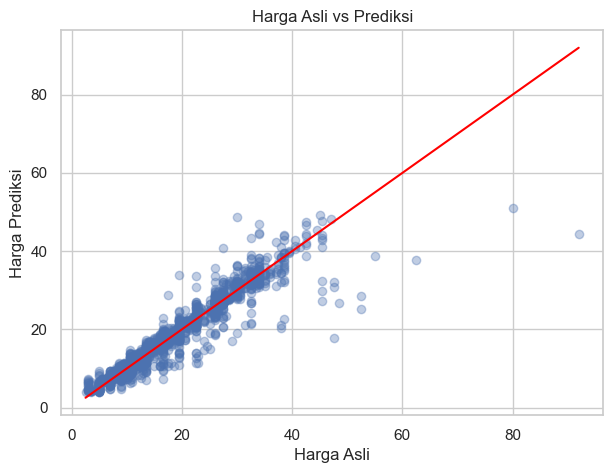

In [12]:
plot_sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)
actual_values = y_test.loc[plot_sample.index]
predicted_values = best_model.predict(plot_sample)

plt.figure(figsize=(7, 5))
plt.scatter(actual_values, predicted_values, alpha=0.35)
plt.plot([actual_values.min(), actual_values.max()], [actual_values.min(), actual_values.max()], color="red")
plt.title("Harga Asli vs Prediksi")
plt.xlabel("Harga Asli")
plt.ylabel("Harga Prediksi")
plt.show()






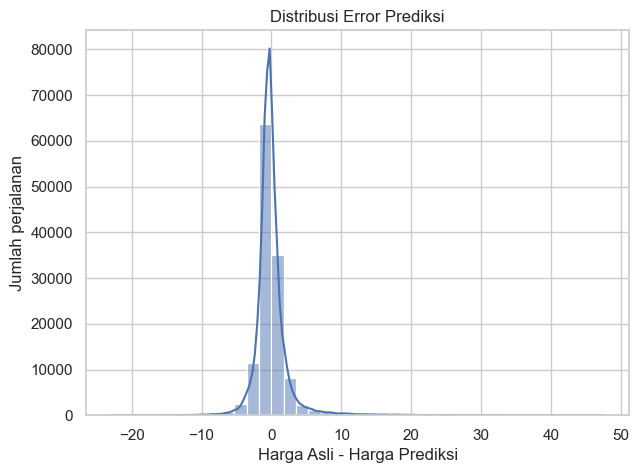

In [13]:
all_predictions = best_model.predict(X_test)
residuals = y_test - all_predictions

plt.figure(figsize=(7, 5))
if HAS_SEABORN:
    sns.histplot(residuals, bins=40, kde=True)
else:
    plt.hist(residuals, bins=40, edgecolor="black")
plt.title("Distribusi Error Prediksi")
plt.xlabel("Harga Asli - Harga Prediksi")
plt.ylabel("Jumlah perjalanan")
plt.show()






In [14]:
final_summary = pd.DataFrame({
    "Item": [
        "Baris sebelum cleaning",
        "Baris setelah cleaning",
        "Fitur yang dipakai",
        "Kolom target",
        "Model yang dilatih",
        "Nama model terbaik",
        "MAE",
        "RMSE",
        "R2 Score",
        "Lokasi model",
    ],
    "Nilai": [
        f"{rows_before_cleaning:,}",
        f"{rows_after_cleaning:,}",
        ", ".join(feature_columns),
        target_column,
        ", ".join(models_trained),
        best_model_name,
        f"{best_metrics['MAE']:.4f}",
        f"{best_metrics['RMSE']:.4f}",
        f"{best_metrics['R2 Score']:.4f}",
        str(model_path),
    ],
})

display(final_summary)

print("Ringkasan akhir")
for _, row in final_summary.iterrows():
    print(f"{row['Item']}: {row['Nilai']}")






,Item,Nilai
0,Baris sebelum cleaning,"693,071"
1,Baris setelah cleaning,"637,976"
2,Fitur yang dipakai,"distance, cab_type, source, destination, name,..."
3,Kolom target,price
4,Model yang dilatih,"Dummy Regressor, Ridge Regression, Random Fore..."
5,Nama model terbaik,Random Forest Regressor
6,MAE,1.4254
7,RMSE,2.6181
8,R2 Score,0.9214
9,Lokasi model,D:\SEMESTER 6\DATA MINING\MLOps-Tarif-Transpor...


Ringkasan akhir
Baris sebelum cleaning: 693,071
Baris setelah cleaning: 637,976
Fitur yang dipakai: distance, cab_type, source, destination, name, hour, day, month, day_of_week
Kolom target: price
Model yang dilatih: Dummy Regressor, Ridge Regression, Random Forest Regressor
Nama model terbaik: Random Forest Regressor
MAE: 1.4254
RMSE: 2.6181
R2 Score: 0.9214
Lokasi model: D:\SEMESTER 6\DATA MINING\MLOps-Tarif-Transportasi-Online\models\baseline_price_model.joblib
